### Complete all codes, and finish training and inference

##### Task1

In [ ]:
# =======================1-1-2-pip: Enter the command to view the third-party libraries installed in the current environment.==================


In [2]:
# ==========================1-2-1-unzip: Download the file archive and extract it. ==============


In [1]:
# ==========================1-2-2-env-1: Install transformers ==============
%pip install transformers==4.6.1

  Using cached numpy-1.21.6-cp37-cp37m-win_amd64.whl (14.0 MB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached idna-3.10-py3-none-any.whl (70 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
  Using cached click-8.1.8-py3-none-any.whl (98 kB)
Using legacy setup.py install for sacremoses, since package 'wheel' is not installed.
    Running setup.py install for sacremoses: started
    Running setup.py install for sacremoses: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Dindin\.pyenv\pyenv-win\versions\3.7.8\python.exe -m pip install --upgrade pip' command.


In [2]:
# ==========================1-2-2-env-2: Install torchtext ==============
%pip install torchtext==0.11.0

  Attempting uninstall: torch
    Found existing installation: torch 1.13.1
    Uninstalling torch-1.13.1:
      Successfully uninstalled torch-1.13.1
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Dindin\.pyenv\pyenv-win\versions\3.7.8\python.exe -m pip install --upgrade pip' command.


In [3]:
# ==========================1-2-2-env-3: Install seaborn ==============
%pip install seaborn

  Using cached Pillow-9.5.0-cp37-cp37m-win_amd64.whl (2.5 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Dindin\.pyenv\pyenv-win\versions\3.7.8\python.exe -m pip install --upgrade pip' command.


In [5]:
# ==========================1-2-2-env-4: upgrade jupyter ipywidgets==============
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dindin\.pyenv\pyenv-win\versions\3.7.8\python.exe -m pip install --upgrade pip' command.


In [6]:
# ==========================1-2-2-env-5: Check the successfully installed third-party libraries==============
!pip show transformers
!pip show torchtext
!pip show seaborn

Name: transformers
Version: 4.6.1
Summary: State-of-the-art Natural Language Processing for TensorFlow 2.0 and PyTorch
Home-page: https://github.com/huggingface/transformers
Author: Thomas Wolf, Lysandre Debut, Victor Sanh, Julien Chaumond, Sam Shleifer, Patrick von Platen, Sylvain Gugger, Suraj Patil, Stas Bekman, Google AI Language Team Authors, Open AI team Authors, Facebook AI Authors, Carnegie Mellon University Authors
Author-email: thomas@huggingface.co
License: Apache
Location: c:\users\dindin\.pyenv\pyenv-win\versions\3.7.8\lib\site-packages
Requires: regex, tqdm, huggingface-hub, importlib-metadata, requests, filelock, sacremoses, tokenizers, packaging, numpy
Required-by: 
Name: torchtext
Version: 0.11.0
Summary: Text utilities and datasets for PyTorch
Home-page: https://github.com/pytorch/text
Author: PyTorch core devs and James Bradbury
Author-email: jekbradbury@gmail.com
License: BSD
Location: c:\users\dindin\.pyenv\pyenv-win\versions\3.7.8\lib\site-packages
Requires: tqdm,

In [1]:
import ipywidgets
print(ipywidgets.__version__)  # Should show 7.6.0 or higher

8.1.8


##### Task2

In [1]:
from tqdm.notebook import tqdm
tqdm.pandas()

import pickle
import time
import string
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import torch
# from torchtext.legacy import data
import torch.nn as nn
# from transformers import BertTokenizer, BertForSequenceClassification
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns


# ==========================2-1-1-device: Print the training device used in the current environment ==============

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)
# # =================================================================================

PATH = 'data'

RANDOM_STATE = 1

cuda


# Loading and processing dataset

### Load raw dataset

In [2]:
# ==========================2-2-1-load: Load data ==============
raw_df = pd.read_csv('./data/news_dataset.csv')
# ==================================================================

In [3]:
# ==========================2-2-2-print: Print the headers of the CSV file==============
raw_df.head()
# ===========================================================================

,Title,Body,Summary,Category
0,Fed chief warning on US deficit,Federal Reserve chairman Alan Greenspan has wa...,Federal Reserve chairman Alan Greenspan has wa...,business
1,Saudi ministry to employ women,Women will be employed in Saudi Arabia's forei...,Women will be employed in Saudi Arabia's forei...,business
2,Deutsche Telekom sees mobile gain,German telecoms firm Deutsche Telekom saw stro...,"A year ago, debt was more than 11bn euros high...",business
3,"Steel firm 'to cut' 45,000 jobs","Mittal Steel, one of the world's largest steel...","Mittal Steel, one of the world's largest steel...",business
4,EU aiming to fuel development aid,European Union finance ministers meet on Thurs...,Any tax would only be implemented after full c...,business


In [4]:
# ==========================2-2-3-print: Check the number of rows and columns of the data==============
# raw_df.shape
raw_df.info()
# ===========================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Title     2225 non-null   object
 1   Body      2225 non-null   object
 2   Summary   2225 non-null   object
 3   Category  2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB


In [5]:
# ==========================2-2-4-print: Print the first 3 rows of the training data==============
raw_df.iloc[:3,:]
# ===========================================================================

,Title,Body,Summary,Category
0,Fed chief warning on US deficit,Federal Reserve chairman Alan Greenspan has wa...,Federal Reserve chairman Alan Greenspan has wa...,business
1,Saudi ministry to employ women,Women will be employed in Saudi Arabia's forei...,Women will be employed in Saudi Arabia's forei...,business
2,Deutsche Telekom sees mobile gain,German telecoms firm Deutsche Telekom saw stro...,"A year ago, debt was more than 11bn euros high...",business


In [6]:
# =====================2-3-1-print: Print the categories contained in the Category column====================
column_name = 'Category'

unique_categories = raw_df[column_name].unique()
print("five categories: ", unique_categories)
# ===========================================================================

five categories:  ['business' 'entertainment' 'politics' 'sport' 'tech']


### Pre-process text

In [7]:
# ==========================2-3-2-count: Count the data volume for each field.==============
counts = raw_df.groupby([column_name]).count()
print("\nrows of per categor: ")
print(counts)
# ===========================================================================


rows of per categor: 
               Title  Body  Summary
Category                           
business         510   510      510
entertainment    386   386      386
politics         417   417      417
sport            511   511      511
tech             401   401      401


In [8]:
# ========================2-3-3-save：Screenshot of code: delete data and save new CSV file================
# 1. Calculate the number of the smallest category
min_count = counts.min().iloc[0]
print(min_count)
# 2. Group by category and randomly sample min_count rows for each group
raw_df = raw_df.groupby([column_name], group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=42))
# 3. Reset index
raw_df = raw_df.reset_index(drop=True)
# 4. Verify the result
print("\nAfter downsampling:")
print(raw_df[column_name].value_counts().sort_index())
# 5. save new CSV file
raw_df.to_csv('data/downsampled.csv', index=False)

# ===========================================================================

386

After downsampling:
Category
business         386
entertainment    386
politics         386
sport            386
tech             386
Name: count, dtype: int64


C:\Users\Dindin\AppData\Local\Temp\ipykernel_19704\3659940046.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  raw_df = raw_df.groupby([column_name], group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=42))


In [9]:
# =========2-3-4-preprocess: Define the text truncation length and implement a function for text truncation==============
MAX_SEQ_LEN = 150

def preprocess_text(text):
    text = text.split()
    text = text[:150]
    text = ' '.join(text)
    text = text.lower()
    return text
# ===========================================================================

In [10]:
raw_df['Title'] = raw_df['Title'].apply(lambda x: preprocess_text(x))
raw_df['Body'] = raw_df['Body'].apply(lambda x: preprocess_text(x))
raw_df['Summary'] = raw_df['Summary'].apply(lambda x: preprocess_text(x))

### Prepare columns for concatenated texts and integer labels

In [11]:
# =================================2-4-1-newDF============================
labels = {k:i for i, k in enumerate(unique_categories)}
df = pd.DataFrame(columns=['label', 'titlebody'])
df['label'] = raw_df['Category'].map(labels)
df['titlebody'] = raw_df['Title'] + ". " + raw_df['Body']
# ======================================================================================

In [12]:
# =================================2-4-2-printDF==========================
df
# ======================================================================================

,label,titlebody
0,0,ba to suspend two saudi services. british airw...
1,0,minister hits out at yukos sale. russia's rena...
2,0,tsunami slows sri lanka's growth. sri lanka's ...
3,0,news corp makes $5.4bn fox offer. news corpora...
4,0,lloyd's of london head chides fsa. the head of...
...,...,...
1925,4,dublin hi-tech labs to shut down. dublin's hi-...
1926,4,warnings on woeful wi-fi security. companies a...
1927,4,"when technology gets personal. in 2020, whippi..."
1928,4,web radio takes spanish rap global. spin the r...


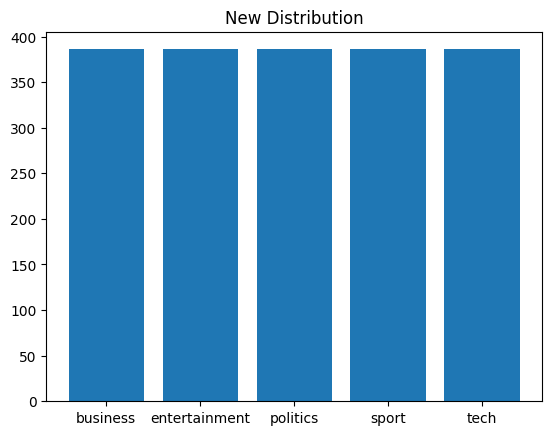

In [13]:
# ===============================2-5-1-virtualization========================
category, values = np.unique(df['label'], return_counts=True)
plt.title("New Distribution")
plt.bar(category, values)
plt.xticks(np.arange(5), labels)
plt.show()
# =========================================================================================

### Split dataset into train, valid, test

In [14]:
# =============================Subtask 6===================================

#  1. 2-6-1-LabelDict
LABEL_MAPPING = {v:k for k, v in labels.items()}

# 2. 2-6-2-set
TRAIN_RATIO = 0.8
VALID_TEST_RATIO = 0.5

# 3. 2-6-3-split
def split_category_data(df_category, train_ratio=TRAIN_RATIO, random_state=RANDOM_STATE):
    """
    Split the DataFrame of a single category into train-valid-test sets with a ratio of 8:1:1
    :param df_category: Original DataFrame of a single category
    :param train_ratio: Proportion of the training set (default 0.8)
    :param random_state: Random seed (ensures consistent split results)
    :return: (train_df, valid_df, test_df)
    """
    # Step 1: Split the data into the training set (80%) and the remaining part (20%)
    df_train, df_rem = train_test_split(df_category, train_size=train_ratio, random_state=random_state)
    # Step 2: Split the remaining 20% into the validation set (10%) and the test set (10%)
    df_valid, df_test = train_test_split(df_rem, train_size=VALID_TEST_RATIO, random_state=random_state)
    return df_train, df_valid, df_test
# =====================================================================

In [15]:
# ===========================Subtask7=============================
# 1. Split all categories by label and store them in a dictionary in the format of "category name: corresponding DataFrame data of the category"
category_dfs = {name: df[df["label"] == label] for label, name in LABEL_MAPPING.items()}
category_dfs
# 2. Iterate through each category, perform an 8:1:1 split, and store the results in a dictionary
split_results = {}
for cat_name, cat_df in category_dfs.items():
    train_df, valid_df, test_df = split_category_data(
        cat_df, 
        train_ratio=TRAIN_RATIO, 
        random_state=RANDOM_STATE
    )

    # Save the split results of consultations for different categories
    split_results[cat_name] = {
        'train' : train_df[train_df['label']==labels[cat_name]],
        'valid' : valid_df[valid_df['label']==labels[cat_name]],
        'test' : test_df[test_df['label']==labels[cat_name]],
    }

# 3. Batch merge the train/valid/test sets of all categories
train_data = pd.concat(
    [split_results[cat]['train'] for cat in labels.keys()],    # Complete the code
    ignore_index=True,
    sort=False)

valid_data = pd.concat(
    [split_results[cat]['valid'] for cat in labels.keys()],   
    ignore_index=True,
    sort=False)

test_data = pd.concat(
    [split_results[cat]['test'] for cat in labels.keys()],  
    ignore_index=True,
    sort=False)

In [16]:
# Save to file
train_data.to_csv(PATH + '/train.csv', index=False)
valid_data.to_csv(PATH + '/valid.csv', index=False)
test_data.to_csv(PATH + '/test.csv', index=False)

In [17]:
 # ===============================2-7-2-train ======================
train_data = pd.read_csv(PATH + '/train.csv')
train_data

,label,titlebody
0,0,lufthansa flies back to profit. german airline...
1,0,algeria hit by further gas riots. algeria suff...
2,0,sa unveils 'more for all' budget. the south af...
3,0,low-cost airlines hit eurotunnel. channel tunn...
4,0,'standoff' on deutsche's lse bid. deutsche boe...
...,...,...
1535,4,set your television to wow. television started...
1536,4,"creator of first apple mac dies. jef raskin, h..."
1537,4,game firm holds 'cast' auditions. video game f...
1538,4,honour for uk games maker. leading british com...


In [18]:
 # ===============================2-7-2-valid ======================
valid_data = pd.read_csv(PATH + '/valid.csv')
valid_data

,label,titlebody
0,0,'post-christmas lull' in lending. uk mortgage ...
1,0,eu to probe alitalia 'state aid'. the european...
2,0,mexican in us send $16bn home. mexican laboure...
3,0,giving financial gifts to children. your child...
4,0,"parmalat boasts doubled profits. parmalat, the..."
...,...,...
190,4,games 'deserve a place in class'. computer gam...
191,4,'podcasters' look to net money. nasa is doing ...
192,4,mobile networks seek turbo boost. third-genera...
193,4,football manager scores big time. for the past...


In [19]:
 # ===============================2-7-2-test ======================
test_data = pd.read_csv(PATH + '/test.csv')
test_data

,label,titlebody
0,0,nigeria to boost cocoa production. the governm...
1,0,quake's economic costs emerging. asian governm...
2,0,standard life concern at lse bid. standard lif...
3,0,air china in $1bn london listing. china's nati...
4,0,wembley firm won't make a profit. shares in mu...
...,...,...
190,4,xbox power cable 'fire fear'. microsoft has sa...
191,4,pc photo printers challenge pros. home printed...
192,4,europe backs digital tv lifestyle. how people ...
193,4,games win for blu-ray dvd format. the next-gen...


# Fine-tuning a pre-trained Bert model

Uses “bert-base-uncased” version of BERT, which is pre-trained on lower-cased English text

(with 12-layer, 768-hidden, 12-heads, 110M parameters)

For the purposes of fine-tuning, recommend choosing from the following values 

*   **Batch size:** 8, 16
*   **Learning rate (Adam):** 5e-5, 3e-5, 2e-5
*   **Number of epochs:** 2, 3, 4

In [21]:
# bert_path = "./bert-base-uncased"
# # tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# tokenizer = BertTokenizer.from_pretrained(bert_path)
# # Model parameters
# BATCH_SIZE = 8
# MAX_SEQ_LEN = 200
# PAD_INDEX = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
# UNK_INDEX = tokenizer.convert_tokens_to_ids(tokenizer.unk_token)

# Fields
# label_field = data.Field(sequential=False, use_vocab=False, batch_first=True, dtype=torch.float)
# text_field = data.Field(use_vocab=False, tokenize=tokenizer.encode, lower=False, include_lengths=False, batch_first=True, fix_length=MAX_SEQ_LEN, pad_token=PAD_INDEX, unk_token=UNK_INDEX)
# fields = [('label', label_field), ('titlebody', text_field)]

# # TabularDataset
# train, valid, test = data.TabularDataset.splits(path=PATH, train='train.csv', validation='valid.csv', test='test.csv', format='CSV', fields=fields, skip_header=True)

# # Iterators
# train_iter = data.BucketIterator(train, batch_size=BATCH_SIZE, sort_key=lambda x: len(x.titlebody), device=device, train=True, sort=True, sort_within_batch=True)
# valid_iter = data.BucketIterator(valid, batch_size=BATCH_SIZE, sort_key=lambda x: len(x.titlebody), device=device, train=True, sort=True, sort_within_batch=True)
# test_iter = data.Iterator(test, batch_size=BATCH_SIZE, device=device, train=False, shuffle=False, sort=False)

In [20]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

bert_path = "./bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_path)

# Model parameters
BATCH_SIZE = 8
MAX_SEQ_LEN = 200

# Custom Dataset
class TextDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_len):
        self.df = pd.read_csv(csv_path)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row['label'], dtype=torch.float)
        encoding = self.tokenizer.encode(
            str(row['titlebody']),
            max_length=self.max_len,
            padding='max_length',
            truncation=True
        )
        text = torch.tensor(encoding, dtype=torch.long)
        return label, text

# Datasets
train_dataset = TextDataset(f"{PATH}/train.csv", tokenizer, MAX_SEQ_LEN)
valid_dataset = TextDataset(f"{PATH}/valid.csv", tokenizer, MAX_SEQ_LEN)
test_dataset  = TextDataset(f"{PATH}/test.csv",  tokenizer, MAX_SEQ_LEN)

# Iterators
train_iter = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_iter = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_iter  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [21]:
# ====================================2-8-1-Model ===========================================================

class BertModel(nn.Module) :
    def __init__(self):
        super(BertModel, self).__init__()
        self.encoder = BertForSequenceClassification.from_pretrained(bert_path, num_labels=5)  #Complete the code

    def forward(self, text, label):
        outputs = self.encoder(input_ids=text, labels=label)
        loss = outputs.loss
        logits = outputs.logits
        return loss, logits
# =========================================================================================================================

### Save data

In [22]:
def save_model(path, model, valid_loss):
    state_dict = {'model_state_dict': model.state_dict(),
                  'valid_loss': valid_loss}
    torch.save(state_dict, path)

# ========================2-7-1-save_metrics===========================

# ===================================================================================

# =========================2-8-1-load_metrics===========================

# ===================================================================================

In [23]:
# ==================2-9-1-save_metrics==============
def save_metrics(path, train_loss_list, valid_loss_list, global_steps_list):
    state_dict = {
        "train_loss_list" :train_loss_list, 
        "valid_loss_list" :valid_loss_list, 
        "global_steps_list" :global_steps_list
    }
    torch.save(state_dict, path)
# ============================================================

In [24]:
# ========================2-10-1-load_metrics=======================
def load_metrics(path):
    state_dict = torch.load(path)  # Complete the code
    return state_dict['train_loss_list'],  state_dict['valid_loss_list'], state_dict['global_steps_list'] 
# ============================================================================

In [25]:
# ========================2-11-1-print_model_params=======================
def print_model_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"total_params: {total_params:,}")           
    print(f"trainable_params: {trainable_params:,}")   
    print(f"Model Size: { (total_params * 4) / 1024 * 1024 } MB (FP32)")     # Complete the code      
    
    return total_params, trainable_params
# ============================================================================

In [28]:
# ========================2-13-1-train_param=======================
model = BertModel().to(device)
print_model_params(model)
# ==========================================================================

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

total_params: 109,486,085
trainable_params: 109,486,085
Model Size: 437944340.0 MB (FP32)


(109486085, 109486085)

In [26]:
# ===================2-13-1-train_param: To be modified.======================
def train(model, optimizer, train_set=train_iter, valid_set=valid_iter,
          num_epochs=5, eval_every = len(train_iter) // 2,
          file_path = PATH, best_valid_loss = float("Inf")):
# ======================================================================

    running_loss = 0.0
    valid_running_loss = 0.0
    global_step = 0
    train_loss_list = []
    valid_loss_list = []
    global_steps_list = []

    inference_time = 0.0
    inference_count = 0

    # Training
    # =========================2-14-1-train: Training mode ===========================
    model.train()
    # ===================================================================================
    
    
    for epoch in tqdm(range(num_epochs)):
        # Perform one full pass over the train set
        print('======= Epoch [{}/{}] ======='.format(epoch+1, num_epochs))

        for labels, titlebody in tqdm(train_set):
            
            labels = labels.type(torch.LongTensor)           
            labels = labels.to(device)
            titlebody = titlebody.type(torch.LongTensor)  
            titlebody = titlebody.to(device)
            start_time = time.time()
            # =========================2-14-1-train: Complete the code for calculating the loss ===========================
            loss, _ = model(titlebody, labels)
            # ============================================================================
            # torch.cuda.synchronize()
            time_taken = time.time() - start_time
            inference_time += time_taken
            inference_count += 1
            # =========================2-15-1-BP===========================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # ============================================================================

            # Update running values
            running_loss += loss.item()
            global_step += 1

# ============================ 2-16-1-bool ====================================
            if global_step % eval_every == 0:          # Complete the code
                model.eval()                             # Complete the code
                with torch.no_grad():                    # Complete the code

                    # Validation loop
                    for labels, titlebody in valid_set:      # Complete the code
                        labels = labels.type(torch.LongTensor)
                        labels = labels.to(device)
                        titlebody = titlebody.type(torch.LongTensor)  
                        titlebody = titlebody.to(device)
                        loss, _ = model(titlebody, labels)                           # Complete the code

                        valid_running_loss += loss.item()                # Complete the code

                # Compute metrics
                average_train_loss = running_loss / eval_every
                average_valid_loss = valid_running_loss / len(valid_set)
                train_loss_list.append(average_train_loss)
                valid_loss_list.append(average_valid_loss)
                global_steps_list.append(global_step)

                # Reset running values
                running_loss = 0.0                
                valid_running_loss = 0.0
                model.train()

                # Log progress
                print('Epoch [{}/{}], Step [{}/{}], Train Loss: {:.4f}, Valid Loss: {:.4f}'
                    .format(epoch+1, num_epochs, global_step, num_epochs*len(train_set),
                            average_train_loss, average_valid_loss))

                # Save Model
                if best_valid_loss > average_valid_loss:                
                    best_valid_loss = average_valid_loss
                    save_model(file_path + '/model.pt', model, best_valid_loss)
                    save_metrics(file_path + '/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)

    save_metrics(file_path + '/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)
    inference_time = inference_time / inference_count
    print("Inference Time: %.4f s" % inference_time)
    print('Training complete!')

In [32]:
# =========================17 Model Init and Training Start ===========================
model = BertModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
train(
    model=model,
    optimizer=optimizer
)
# ============================================================================

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

  0%|          | 0/5 [00:00<?, ?it/s]

======= Epoch [1/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

...

Epoch [3/5], Step [480/965], Train Loss: 0.0283, Valid Loss: 0.0693
Epoch [3/5], Step [576/965], Train Loss: 0.0446, Valid Loss: 0.1216
======= Epoch [4/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [4/5], Step [672/965], Train Loss: 0.0357, Valid Loss: 0.1355
Epoch [4/5], Step [768/965], Train Loss: 0.0183, Valid Loss: 0.0962
======= Epoch [5/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [5/5], Step [864/965], Train Loss: 0.0270, Valid Loss: 0.1157
Epoch [5/5], Step [960/965], Train Loss: 0.0268, Valid Loss: 0.1602
Inference Time: 0.0105 s
Training complete!


### Plot Training and Validation Loss

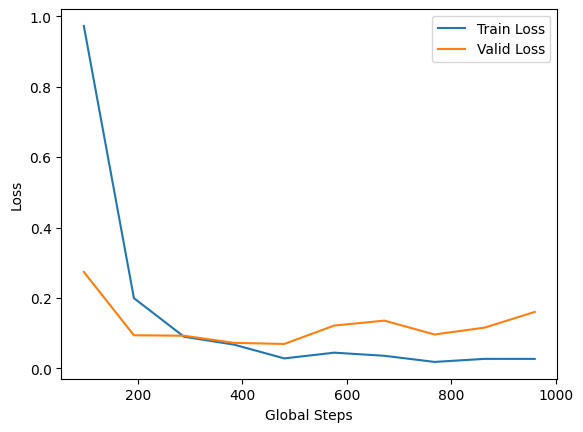

In [33]:
# =========================2-18-1-Virtualization_train ====================
train_loss_list, valid_loss_list, global_steps_list = load_metrics(PATH + '/metrics.pt')
#  1: Plot training loss curve, to be filled
plt.plot(global_steps_list,train_loss_list, label='Train Loss')
# 2: Plot validation loss curve, to be filled
plt.plot(global_steps_list,valid_loss_list, label='Valid Loss')
plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()
# ============================================================================

### Evaluation

In [27]:
# =========================3-1-1-load_model====================
def load_model(path, model):
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict['model_state_dict'])
    return state_dict['valid_loss']
# ======================================================================

In [28]:
def evaluate(model, test_set=test_iter):
    y_pred = []
    y_true = []
    # =========================3-2-1-mode ====================
    model.eval()
    # ======================================================================
    with torch.no_grad():
        

        for labels, titlebody in tqdm(test_set):
            labels = labels.type(torch.LongTensor)           
            labels = labels.to(device)
            titlebody = titlebody.type(torch.LongTensor)  
            titlebody = titlebody.to(device)
            output = model(titlebody, labels)
            _, output = output
            y_pred.extend(torch.argmax(output, 1).tolist())
            y_true.extend(labels.tolist())

    print('Classification Report:')
    # =========================3-3-1-report:  ====================
    
    print(classification_report(y_pred=y_pred, y_true=y_true, target_names=unique_categories))
    # =========================================================================

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
    ax = plt.subplot()
    
    # =========================3-4-1-CM =========================
    sns.heatmap(cm, annot=True, ax=ax,cmap='Blues',fmt='g')
    
    # =========================================================================

    ax.set_title('Confusion Matrix')

    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')

    ax.xaxis.set_ticklabels(['business', 'entertainment', 'politics', 'sport', 'tech'])
    ax.yaxis.set_ticklabels(['business', 'entertainment', 'politics', 'sport', 'tech'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

  0%|          | 0/25 [00:00<?, ?it/s]

Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.95      0.97        39
entertainment       1.00      1.00      1.00        39
     politics       0.95      1.00      0.97        39
        sport       1.00      1.00      1.00        39
         tech       1.00      1.00      1.00        39

     accuracy                           0.99       195
    macro avg       0.99      0.99      0.99       195
 weighted avg       0.99      0.99      0.99       195



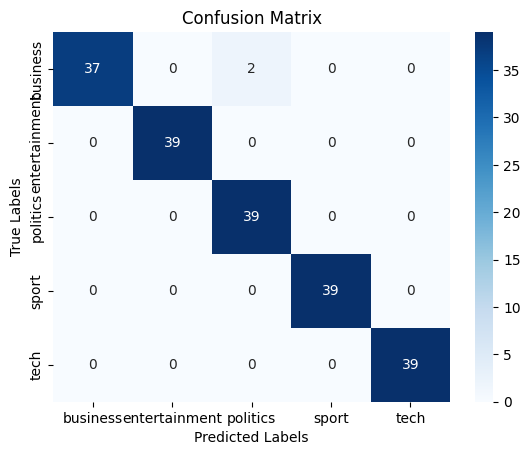

In [38]:
bert_model = BertModel().to(device)
load_model(PATH + '/model.pt', bert_model)
evaluate(bert_model, test_iter)

In [63]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the pre-trained BERT tokenizer and model
bert_path = "./bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_path)
model = BertForSequenceClassification.from_pretrained(bert_path, num_labels=5).to(device)

# Load the model weights
model_path = "./data/model.pt"
# Ensure that the entire state_dict is loaded, not just the model weights
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'], strict=False)  # Use strict=False to ignore mismatched keys
model.eval()

# Define the category labels
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

# Define the preprocessing function
def preprocess_text(text, max_seq_len=200):
    inputs = tokenizer(
        text,
        None,
        add_special_tokens=True,
        max_length=max_seq_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )

    ids = inputs['input_ids']
    mask = inputs['attention_mask']

    return {
        'ids': ids.to(device),
        'mask': mask.to(device)
    }

# Test a single data example
# =========================4-1-1-test_single =========================
def test_single_example(text):
    # Preprocess the input text
    inputs = preprocess_text(text)  # Complete the code
    ids = inputs['ids']
    mask = inputs['mask']

    # Model forward pass
    with torch.no_grad():                                # Complete the code
        # Ensure the forward method is called correctly
        outputs = model(ids, mask)
        print(outputs)                         # Complete the code
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).item()

    # Output the prediction result
    predicted_label = labels[preds]                      # Complete the code
    print(f"Input Text: {text}")
    print(f"Predicted Label: {predicted_label}")
# =========================================================================
    
# Test example
test_text = '''The government announced new measures to boost economic growth.'''
test_single_example(test_text)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

SequenceClassifierOutput(loss=None, logits=tensor([[-0.1107,  0.0981,  0.7253, -0.3813,  0.8507]], device='cuda:0'), hidden_states=None, attentions=None)
Input Text: The government announced new measures to boost economic growth.
Predicted Label: tech


In [64]:

# =========================4-2-1-test_batch =========================
def test_batch_example(texts):
    for t in texts:
        test_single_example(t)
# =================================================================================

In [65]:
# Test examples
test_texts = [
    "The government announced new measures to boost economic growth and create jobs in various sectors.",
    "The football team won the championship after an exciting final match against their rivals.",
    "New smartphone with advanced features and improved camera technology was launched today.",
    "The movie starring famous actors received positive reviews from critics and audiences alike.",
    "Political leaders discussed international relations and trade agreements at the summit.",
    "Stock market showed significant gains as investors responded to positive economic indicators.",
    "Basketball team secured their place in the playoffs with a decisive victory last night.",
    "Tech company unveiled its latest innovation in artificial intelligence and machine learning.",
    "Celebrities attended the red carpet event for the annual film awards ceremony.",
    "Economic policies aimed at reducing inflation were implemented by the central bank."
]
test_batch_example(test_texts)

SequenceClassifierOutput(loss=None, logits=tensor([[-0.1102,  0.1199,  0.7184, -0.4108,  0.8673]], device='cuda:0'), hidden_states=None, attentions=None)
Input Text: The government announced new measures to boost economic growth and create jobs in various sectors.
Predicted Label: tech
SequenceClassifierOutput(loss=None, logits=tensor([[-0.0498,  0.0521,  0.5446, -0.2210,  0.7777]], device='cuda:0'), hidden_states=None, attentions=None)
Input Text: The football team won the championship after an exciting final match against their rivals.
Predicted Label: tech
SequenceClassifierOutput(loss=None, logits=tensor([[-0.1377,  0.1829,  0.7237, -0.5262,  0.8402]], device='cuda:0'), hidden_states=None, attentions=None)
Input Text: New smartphone with advanced features and improved camera technology was launched today.
Predicted Label: tech
SequenceClassifierOutput(loss=None, logits=tensor([[-0.0952,  0.0398,  0.6367, -0.1070,  0.6311]], device='cuda:0'), hidden_states=None, attentions=None)
Inp

### Freeze

In [29]:
# =========================5-1-1-freeze ========================
########## This section requires candidates to freeze some layers of the model, then retrain the model, and compare the effect with full-parameter fine-tuning.#########

import torch
import torch.nn as nn
from transformers import BertForSequenceClassification

# ====================== Model definition ======================
class BertModelFreeze(nn.Module):
    def __init__(self, freeze_strategy="full_bert", freeze_encoder_layers=6):
        """
        Args:
            freeze_strategy: 
                - "full_bert": Freeze the entire BERT backbone (only train the classification head)
                - "partial_bert": Freeze the Embedding layer + the first N Encoder layers
                - "only_embedding": Freeze only the Embedding layer
            freeze_encoder_layers: Only effective for partial_bert; specifies freezing the first N Encoder layers.
        """
        super(BertModelFreeze, self).__init__()
        
        # ========== 1. Load the local BERT model ==========
        # Local directory path: Ensure it contains pytorch_model.bin, config.json, and vocab.txt
        self.encoder = BertForSequenceClassification.from_pretrained(
            "./bert-base-uncased",  # Local model directory (the path where pytorch_model.bin is located)
            num_labels=5,           
            local_files_only=True   # Force loading local files without network access
        )
        
        # ========== 2. Freeze BERT layers according to the strategy.==========
        # obtain the main BERT module (self.encoder.bert)
        bert_backbone = self.encoder.bert
        
        if freeze_strategy == "full_bert":          # Complete the code under this condition
            # Solution 1: Freeze the entire BERT backbone (only train the classification head)
            for param in bert_backbone.parameters():
                param.requires_grad = False
        
        elif freeze_strategy == "partial_bert":     # Complete the code under this condition
            # Solution 2: Freeze the Embedding layer + the first N Encoder layers (Recommended)
            for param in bert_backbone.embeddings.parameters():
                param.requires_grad = False

            # 2. Freeze the first N Encoder layers
            for i in range(freeze_encoder_layers):
                for param in bert_backbone.encoder.layer[i].parameters():
                    param.requires_grad = False
            
        
        elif freeze_strategy == "only_embedding":     # Complete the code under this condition
            # Solution 3: Freeze only the Embedding layer (for large datasets)
            for param in bert_backbone.embeddings.parameters():
                param.requires_grad = False
        
        # Verify the freezing effect (optional:call the parameter statistics function you defined previously)
        # total_params, trainable_params = print_model_params(self)
        # print(f"Trainable parameters after freezing: {trainable_params:,}")

    def forward(self, text, label):
        # Keep the original forward logic unchanged
        loss, logits = self.encoder(text, labels=label)[:2]
        return loss, logits

# ==============================================================================

In [30]:
# =======================5-2-1-print ==============================
frozen_model = BertModelFreeze('partial_bert').to(device)
total_params, trainable_params = print_model_params(frozen_model)
print(f"Trainable parameters after freezing: {trainable_params:,}")
# ===========================================================================

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

total_params: 109,486,085
trainable_params: 43,121,669
Model Size: 437944340.0 MB (FP32)
Trainable parameters after freezing: 43,121,669


##### 5-2-2-ratio



In [31]:
ratio = (trainable_params/total_params)*100
print(ratio)

39.385524653658045


In [ ]:
# ======================5-3-1-train ===============================
optimizer = optim.Adam(filter(lambda p:p.requires_grad, frozen_model.parameters()), lr=2e-5)
train(
    model=frozen_model,
    optimizer=optimizer,
    file_path='frozen'
)
# ===========================================================================

  0%|          | 0/5 [00:00<?, ?it/s]

======= Epoch [1/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [1/5], Step [96/965], Train Loss: 0.8436, Valid Loss: 0.2372
Epoch [1/5], Step [192/965], Train Loss: 0.1943, Valid Loss: 0.1141
======= Epoch [2/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

...

Epoch [3/5], Step [480/965], Train Loss: 0.0442, Valid Loss: 0.1017
Epoch [3/5], Step [576/965], Train Loss: 0.0254, Valid Loss: 0.0657
======= Epoch [4/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [4/5], Step [672/965], Train Loss: 0.0083, Valid Loss: 0.0661
Epoch [4/5], Step [768/965], Train Loss: 0.0124, Valid Loss: 0.0673
======= Epoch [5/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [5/5], Step [864/965], Train Loss: 0.0055, Valid Loss: 0.0774
Epoch [5/5], Step [960/965], Train Loss: 0.0046, Valid Loss: 0.0787
Inference Time: 0.0089 s
Training complete!


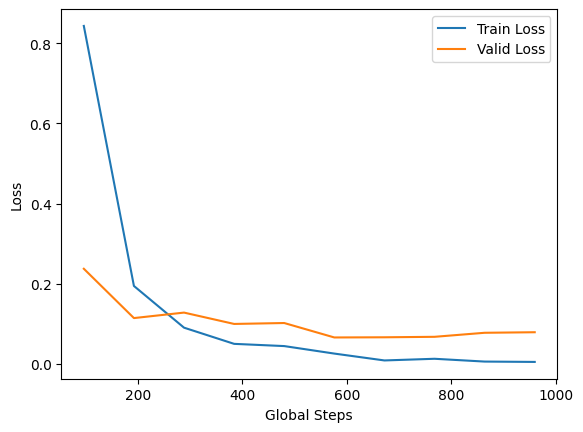

In [34]:
# ======================5-3-2-loss ===============================
train_loss_list, valid_loss_list, global_steps_list = load_metrics('frozen' + '/metrics.pt')
#  1: Plot training loss curve, to be filled
plt.plot(global_steps_list,train_loss_list, label='Train Loss')
# 2: Plot validation loss curve, to be filled
plt.plot(global_steps_list,valid_loss_list, label='Valid Loss')
plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()
# ===========================================================================

In [36]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the pre-trained BERT tokenizer and model
bert_path = "./bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_path)
model = BertForSequenceClassification.from_pretrained(bert_path, num_labels=5).to(device)

# Load the model weights
model_path = "./frozen/model.pt"
# Ensure that the entire state_dict is loaded, not just the model weights
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'], strict=False)  # Use strict=False to ignore mismatched keys
model.eval()

# Define the category labels
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

# Define the preprocessing function
def preprocess_text(text, max_seq_len=200):
    inputs = tokenizer(
        text,
        None,
        add_special_tokens=True,
        max_length=max_seq_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )

    ids = inputs['input_ids']
    mask = inputs['attention_mask']

    return {
        'ids': ids.to(device),
        'mask': mask.to(device)
    }

# Test a single data example
# =========================4-1-1-test_single =========================
def test_single_example(text):
    # Preprocess the input text
    inputs = preprocess_text(text)  # Complete the code
    ids = inputs['ids']
    mask = inputs['mask']

    # Model forward pass
    with torch.no_grad():                                # Complete the code
        # Ensure the forward method is called correctly
        outputs = model(ids, mask)
        print(outputs)                         # Complete the code
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).item()

    # Output the prediction result
    predicted_label = labels[preds]                      # Complete the code
    print(f"Input Text: {text}")
    print(f"Predicted Label: {predicted_label}")
# =========================================================================
    
# Test example
test_text = '''The government announced new measures to boost economic growth.'''
test_single_example(test_text)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training o

SequenceClassifierOutput(loss=None, logits=tensor([[-0.4257, -0.5504,  0.1331,  0.4510,  0.0595]], device='cuda:0'), hidden_states=None, attentions=None)
Input Text: The government announced new measures to boost economic growth.
Predicted Label: sport
